# Synthetic Data Experiment Series
### cylmix-2d-low-strong
- Data generator: Mixture of Cylindrical distribution
- Data dimension: 2d
- Separability between clusters: low
- Cross-covariance: strong


## 01 - Data Generation

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd

%matplotlib widget
import cyl_lvm as clvm
from experiment.synthetic_data import experiment_helper as mod


rng = np.random.RandomState(7)
D_GAUSS = 2
D_VMF = 2
N = 10000

In [2]:
# cylmix-2d-low-strong
angles = np.deg2rad([0.0, 25.0, -25.0])

cyl_components = [
    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.00, 0.00]),
        cross_cov=np.array([[ 0.42, -0.24],
                            [ 0.28,  0.36]]),
        cond_cov=np.array([[1.35, 0.40],
                           [0.40, 1.05]]),
        mu_vmf=mod.unit([np.cos(angles[0]), np.sin(angles[0])]),
        kappa=5.0,
    ),

    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.45, 0.20]),
        cross_cov=np.array([[-0.34,  0.30],
                            [ 0.24, -0.38]]),
        cond_cov=np.array([[1.10, 0.25],
                           [0.25, 1.25]]),
        mu_vmf=mod.unit([np.cos(angles[1]), np.sin(angles[1])]),
        kappa=5.0,
    ),

    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.15, 0.55]),
        cross_cov=np.array([[ 0.30,  0.34],
                            [-0.36,  0.22]]),
        cond_cov=np.array([[ 1.25, -0.30],
                           [-0.30,  1.15]]),
        mu_vmf=mod.unit([np.cos(angles[2]), np.sin(angles[2])]),
        kappa=4.5,
    ),
]

cyl_weights = np.array([0.36, 0.34, 0.30], dtype=float)

generator = clvm.MixtureModel(components=cyl_components,
                               weights=cyl_weights,
                               init="k-means",
                               rng=rng)

# create sample
x, labels = generator.sample(N, rng=rng, return_labels=True)
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = mod.unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

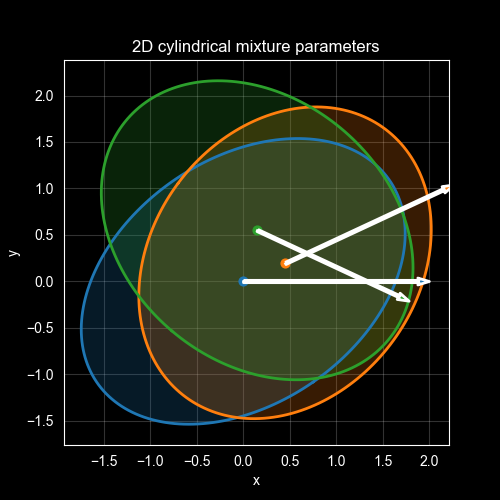

In [3]:
fig, ax = mod.plot_cylindrical_components_2d(generator, arrow_scale=2.0)

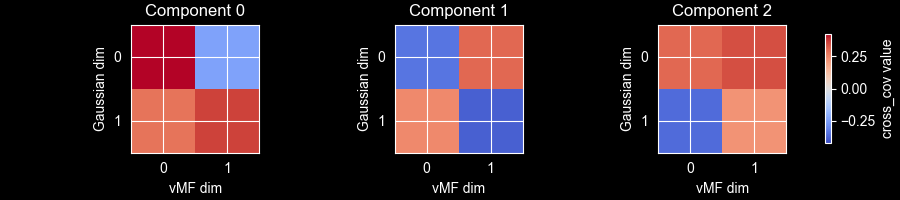

In [4]:
mod.plot_cross_cov_matrices(generator.components, cmap="coolwarm")

## 02 - Models training

In [5]:
setup = {"cylmix_l1": 3,
         "noisy_cylmix_l1": 3,
         "indcylmix_l1": 3,
         "noisy_indcylmix_l1": 3,
         "mom_l1": 4,
         "mom_l2": 2,
         "noisy_mom_l1": 4,
         "noisy_mom_l2": 2,
         "isomom_l1": 4,
         "isomom_l2": 2,
         "noisy_isomom_l1": 4,
         "noisy_isomom_l2": 2,
}

In [6]:
models = mod.train_all_models(D_GAUSS, x, x_noisy,
                              setup=setup)
cylmix, noisy_cylmix, indcylmix, noisy_indcylmix, mom, noisy_mom, isomom, noisy_isomom = models

EM iterations
Cylindrical mixture
   01 No noise: 60
   02 Noisy: 66
Independent cylindrical mixture
   03 No noise: 31
   04 Noisy: 33
Mixture of mixtures
   05 No noise: 53
   06 Noisy: 53
Isolation mixture of mixtures
   07 No noise: 60
   08 Noisy: 58


## 03 - Model comparison

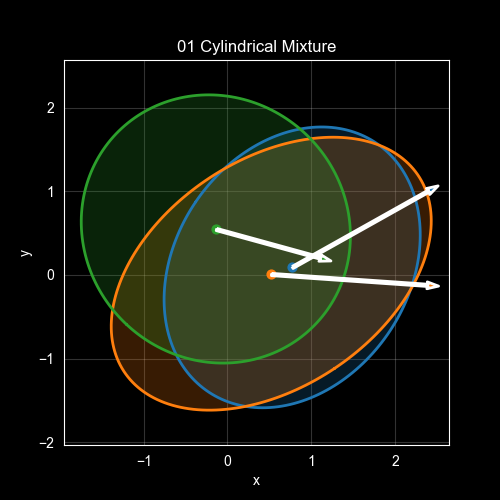

In [7]:
fig, ax = mod.plot_cylindrical_components_2d(cylmix,
                                             arrow_scale=2.0,
                                             title=f"01 Cylindrical Mixture")

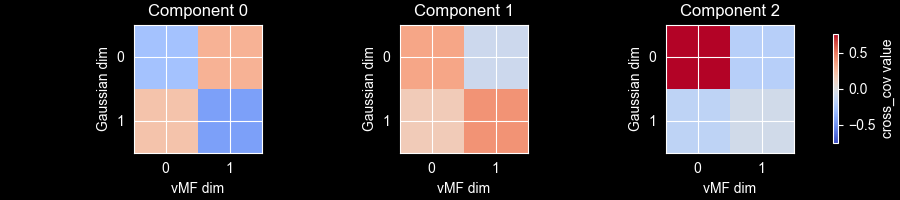

In [8]:
mod.plot_cross_cov_matrices(cylmix.components, cmap="coolwarm")

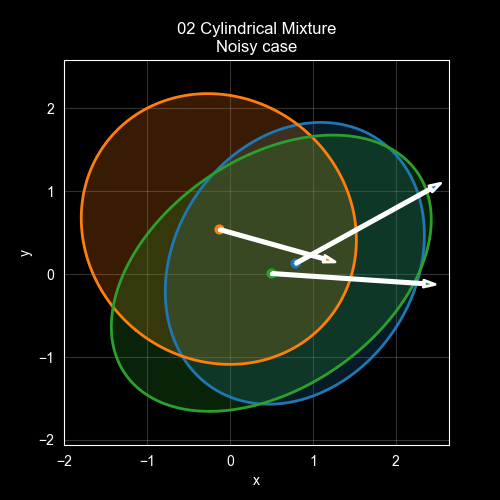

In [9]:
fig, ax = mod.plot_cylindrical_components_2d(noisy_cylmix,
                                             arrow_scale=2.0,
                                             title=f"02 Cylindrical Mixture\nNoisy case")

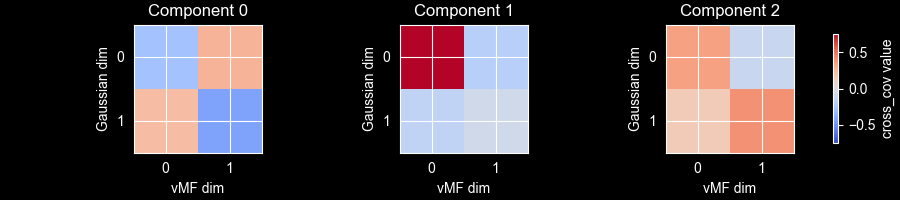

In [10]:
mod.plot_cross_cov_matrices(noisy_cylmix.components, cmap="coolwarm")

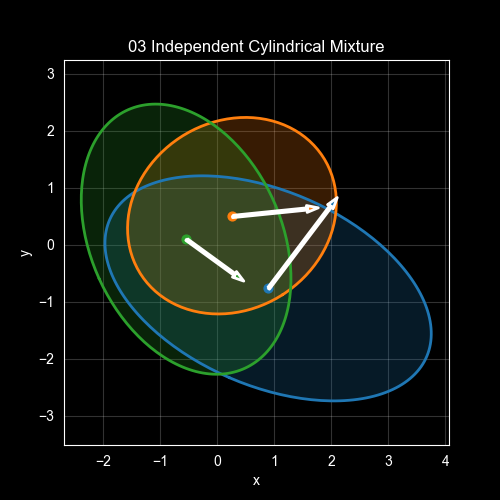

In [11]:
fig, ax = mod.plot_cylindrical_components_2d(indcylmix,
                                             arrow_scale=2.0,
                                             title=f"03 Independent Cylindrical Mixture")

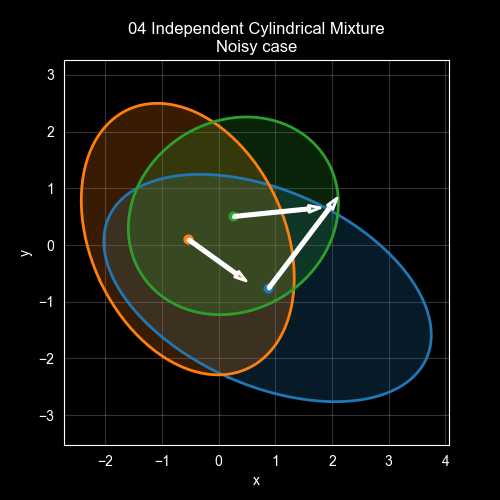

In [12]:
fig, ax = mod.plot_cylindrical_components_2d(noisy_indcylmix,
                                             arrow_scale=2.0,
                                             title=f"04 Independent Cylindrical Mixture\nNoisy case")

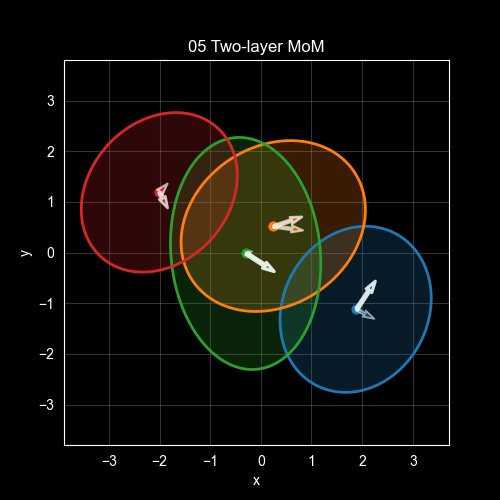

In [13]:
fig, ax = mod.plot_mom_components_2d(mom, arrow_scale=2.0,
                                  title=f"05 Two-layer MoM")

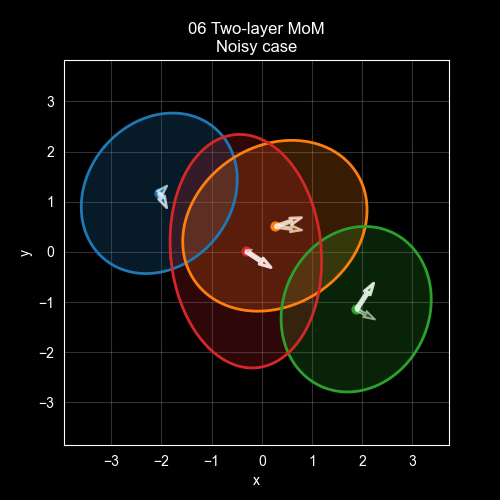

In [14]:
fig, ax = mod.plot_mom_components_2d(noisy_mom, arrow_scale=2.0,
                                  title=f"06 Two-layer MoM\nNoisy case")

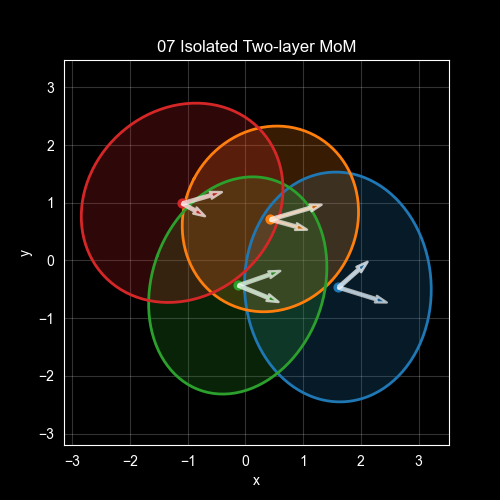

In [15]:
fig, ax = mod.plot_mom_components_2d(isomom, arrow_scale=2.0,
                                  title=f"07 Isolated Two-layer MoM")

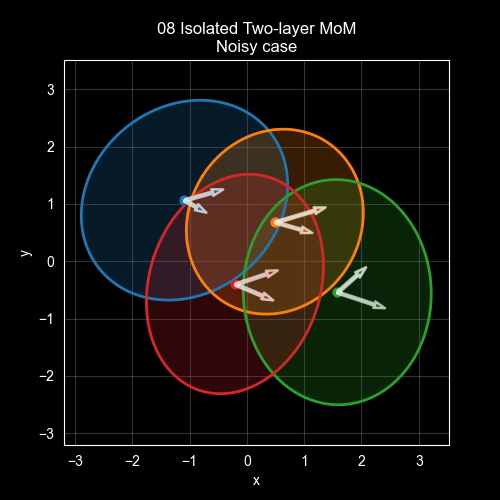

In [16]:
fig, ax = mod.plot_mom_components_2d(noisy_isomom, arrow_scale=2.0,
                                  title=f"08 Isolated Two-layer MoM\nNoisy case")